In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import Counter

In [2]:
merged_read_location = '../output/merged_df.pkl'

with open(merged_read_location, 'rb') as f:
    merged_df = pickle.load(f)
print(f"Loaded merged dataset: {len(merged_df)} rows, {merged_df.shape[1]} columns")
merged_df.head()

Loaded merged dataset: 462785 rows, 14 columns


,platform,name,filename,summary,release_date,release_year,genres,developer,publisher,players,cooperative,rating,user_rating,version
0,Sony PlayStation,&: Sora no Mukou de Saki Masuyou ni,NaN,'&' - Sora no Mukou de Sakimasu you ni is the ...,NaT,<NA>,Visual Novel,Akatsuki Works,Spike Chunsoft,1.0,False,<NA>,7.145833,NaN
4,Web Browser,& in the War I Find You,NaN,When the world has gone crazy - please hold on...,NaT,<NA>,"Indie, Visual Novel",Lawrence Marable,Lawrence Marable,NaN,<NA>,<NA>,NaN,NaN
5,Windows,&&,NaN,A bizarre role-playing game in an alien landsc...,2015-12-31,<NA>,"Adventure, Role-playing (RPG)",Olvin Weplanis,Olvin Weplanis,NaN,<NA>,<NA>,NaN,NaN
6,Google Android,&0,NaN,Detective otome game.,2022-05-30,<NA>,"Simulator, Visual Novel",Coly,Coly,NaN,<NA>,<NA>,NaN,NaN
8,Commodore 64,'43: One Year After,NaN,'43 - One Year After is a vertical-scrolling s...,NaT,1986,Shooter,Greve Graphics,Action Software,1.0,False,<NA>,7.750000,NaN


## 1. Missingness Analysis

In [3]:
missingness = merged_df.isnull().sum()
missing_pct = (missingness / len(merged_df) * 100).round(2)
missing_df = pd.DataFrame({'count': missingness, 'percentage': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False)
print("Missingness by field:")
print(missing_df)

Missingness by field:
               count  percentage
version       462785      100.00
filename      426421       92.14
release_year  403393       87.17
rating        384600       83.11
user_rating   324952       70.22
players       320947       69.35
cooperative   304487       65.79
publisher     159846       34.54
developer     129719       28.03
release_date  124135       26.82
genres         66880       14.45
summary        52818       11.41


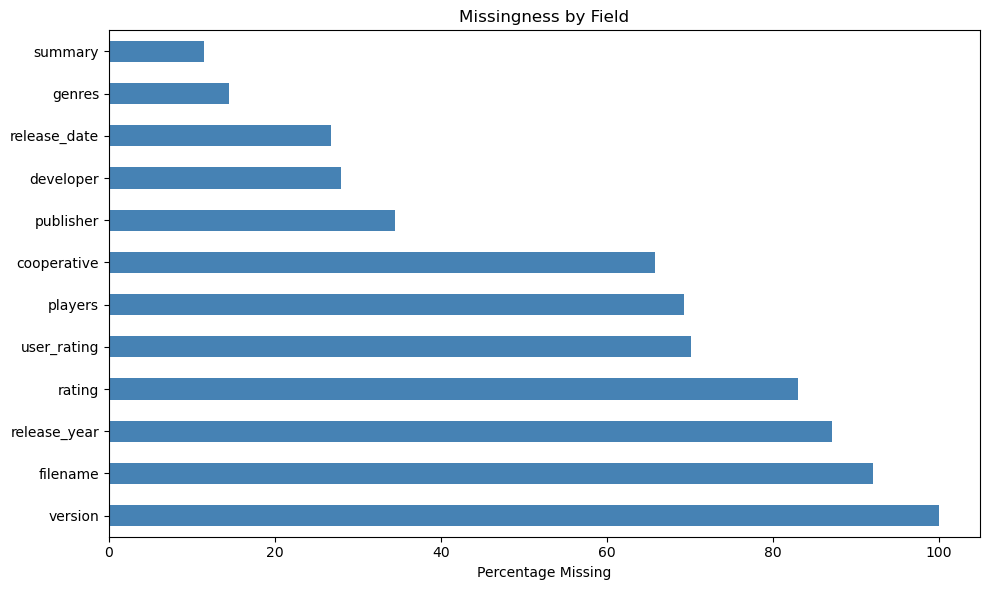

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_df['percentage'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Percentage Missing')
ax.set_title('Missingness by Field')
plt.tight_layout()
plt.show()

In [5]:
metadata_fields = ['summary', 'genres', 'release_year']

print("Metadata completeness by row:")
for i in range(len(metadata_fields)):
    cols = metadata_fields[:i+1]
    row_count = merged_df[cols].notna().all(axis=1).sum()
    row_pct = (row_count / len(merged_df)) * 100
    print(f"  {tuple(cols)} -> {row_pct:.2f}% ({row_count:,}/{len(merged_df):,})")

Metadata completeness by row:
  ('summary',) -> 88.59% (409,967/462,785)
  ('summary', 'genres') -> 83.19% (385,008/462,785)
  ('summary', 'genres', 'release_year') -> 11.29% (52,238/462,785)


## 2. Platform Analysis

In [6]:
platform_counts = merged_df['platform'].value_counts()
print(f"Unique platforms: {len(platform_counts)}")
print("\nTop 20 platforms:")
print(platform_counts.head(20))
print(f"\nPlatforms with only 1 game: {(platform_counts == 1).sum()}")

Unique platforms: 276

Top 20 platforms:
platform
Windows                          133904
Arcade                            41486
Mac                               23329
Nintendo Switch                   19933
Linux                             15811
Google Android                    15143
iOS                               14481
Commodore 64                      14360
Sony PlayStation                  13074
Sony PlayStation 4                10047
Web Browser                        9583
Commodore Amiga                    9140
MS-DOS                             8782
Microsoft Xbox One                 7656
Nintendo DS                        7384
Nintendo Wii                       7240
Sony PlayStation 3                 5548
Sony PlayStation 5                 5090
Sinclair ZX Spectrum               4709
Nintendo Entertainment System      4230
Name: count, dtype: int64

Platforms with only 1 game: 15


In [7]:
platform_lower = merged_df['platform'].str.lower()
lower_counts = Counter(platform_lower)
duplicates = {k: v for k, v in lower_counts.items() if v > 1}
print(f"Platform names differing only by case: {len(duplicates)}")
for name, count in sorted(duplicates.items())[:30]:
    variants = [p for p in merged_df['platform'].unique() if p.lower() == name]
    print(f"  '{name}' -> {count} variants: {variants}")

Platform names differing only by case: 261
  '1292 advanced programmable video system' -> 15 variants: ['1292 Advanced Programmable Video System']
  '3do' -> 446 variants: ['3DO']
  'aamber pegasus' -> 7 variants: ['Aamber Pegasus']
  'acorn archimedes' -> 324 variants: ['Acorn Archimedes']
  'acorn atom' -> 83 variants: ['Acorn Atom']
  'acorn electron' -> 481 variants: ['Acorn Electron']
  'advanced pico beena' -> 8 variants: ['Advanced Pico Beena']
  'airconsole' -> 6 variants: ['AirConsole']
  'amazon fire tv' -> 61 variants: ['Amazon Fire TV']
  'amstrad cpc' -> 3208 variants: ['Amstrad CPC']
  'amstrad gx4000' -> 28 variants: ['Amstrad GX4000']
  'analogue electronics' -> 2 variants: ['Analogue electronics']
  'apf imagination machine' -> 12 variants: ['APF Imagination Machine']
  'apogee bk-01' -> 67 variants: ['Apogee BK-01']
  'apple ii' -> 2679 variants: ['Apple II']
  'apple iigs' -> 224 variants: ['Apple IIGS']
  'arcade' -> 41486 variants: ['Arcade']
  'arcadia 2001' -> 33

In [8]:
sony_platforms = merged_df[merged_df['platform'].str.contains('Play', case=False, na=False)]['platform'].unique()
print("Sony platform variants:")
for p in sorted(sony_platforms):
    print(f"  {p}")

Sony platform variants:
  Blu-ray Player
  DVD Player
  Playdate
  Playdia
  Plug & Play
  Sony PlayStation
  Sony PlayStation 2
  Sony PlayStation 3
  Sony PlayStation 4
  Sony PlayStation 5
  Sony PlayStation Portable
  Sony PlayStation VR
  Sony PlayStation VR2
  Sony PlayStation Vita


In [9]:
sega_platforms = merged_df[merged_df['platform'].str.contains('Sega', case=False, na=False)]['platform'].unique()
print("Sega platform variants:")
for p in sorted(sega_platforms):
    print(f"  {p}")

Sega platform variants:
  Sega CD
  Sega Dreamcast
  Sega Game Gear
  Sega Genesis
  Sega Genesis 32X
  Sega Hikaru
  Sega Master System
  Sega Mega Drive
  Sega Model 1
  Sega Model 2
  Sega Model 3
  Sega Naomi
  Sega Naomi 2
  Sega Pico
  Sega SG-1000
  Sega ST-V
  Sega Saturn
  Sega Triforce


In [10]:
nintendo_platforms = merged_df[merged_df['platform'].str.contains('Nintendo|Super Nintendo|Game Boy|NES|SNES|N64|GameCube|DS|Wii|Switch|3DS|Virtual Boy|Satellite| Satellaview|Pokemon Mini|Game & Watch', case=False, na=False)]['platform'].unique()
print("Nintendo platform variants:")
for p in sorted(nintendo_platforms):
    print(f"  {p}")

Nintendo platform variants:
  EDSAC
  Grandstand Tutor
  Imlac PDS-1
  Nintendo 3DS
  Nintendo 64
  Nintendo 64DD
  Nintendo DS
  Nintendo Entertainment System
  Nintendo Famicom Disk System
  Nintendo Game & Watch
  Nintendo Game Boy
  Nintendo Game Boy Advance
  Nintendo Game Boy Color
  Nintendo GameCube
  Nintendo Pokémon Mini
  Nintendo Satellaview
  Nintendo Switch
  Nintendo Virtual Boy
  Nintendo Wii
  Nintendo Wii U
  SDS Sigma 7
  Sega Genesis
  Sega Genesis 32X
  Super Nintendo Entertainment System


## 3. Name Analysis

In [11]:
print(f"Total entries: {len(merged_df)}")
print(f"Unique names: {merged_df['name'].nunique()}")
dup_rate = merged_df['name'].duplicated().sum() / len(merged_df) * 100
print(f"Duplicate names (same name, different platform entry): {merged_df['name'].duplicated().sum()} ({dup_rate:.2f}%)")

Total entries: 462785
Unique names: 302028
Duplicate names (same name, different platform entry): 160757 (34.74%)


In [12]:
short_names = merged_df[merged_df['name'].str.len() <= 3]
print(f"Names with 3 or fewer characters: {len(short_names)}")
print("\nExamples:")
print(short_names['name'].value_counts().head(20))

Names with 3 or fewer characters: 1567

Examples:
name
Uno    21
Qix    13
War    13
Sdi    11
Fez    11
Xor    11
Orx    10
Z      10
Hex    10
Jet     9
Hue     9
Up      9
Wiz     8
Eye     8
Red     8
Nam     8
Dex     8
F1      7
Hoa     7
D       7
Name: count, dtype: int64


In [13]:
region_tag_pattern = r'\(USA|PAL|JAP|EUR|WORLD|REGION|FREEPLAY\)'
region_tags = merged_df[merged_df['name'].str.contains(region_tag_pattern, case=False, na=False)]
print(f"Names with region tags: {len(region_tags)} ({len(region_tags)/len(merged_df)*100:.2f}%)")

rom_hack_pattern = r'\[!\]|\[a\]|\[T\+|\[M\+|\[b|\[C|\[O|\[S|\[U'
rom_hacks = merged_df[merged_df['name'].str.contains(rom_hack_pattern, na=False)]
print(f"Names with ROM hack tags: {len(rom_hacks)} ({len(rom_hacks)/len(merged_df)*100:.2f}%)")

Names with region tags: 11104 (2.40%)
Names with ROM hack tags: 54 (0.01%)


In [14]:
version_pattern = r'v\d+\.\d+|Ver\.|v\d+|Version \d+'
versions = merged_df[merged_df['name'].str.contains(version_pattern, case=False, na=False)]
print(f"Names with version indicators: {len(versions)} ({len(versions)/len(merged_df)*100:.2f}%)")
print("\nExamples:")
print(versions['name'].value_counts().head(10))

Names with version indicators: 3906 (0.84%)

Examples:
name
Danganronpa V3: Killing Harmony    8
Driv3r                             6
The Last V8                        6
Micro Machines V4                  5
Surv1v3                            5
Sniper Elite V2                    5
Sniper Elite V2 Remastered         5
Superstars V8 Racing               5
NBA Street V3                      5
Floppy Knights: Version 2.0        4
Name: count, dtype: int64


## 4. Summary Analysis

In [15]:
merged_df['summary_word_count'] = merged_df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
merged_df['summary_length'] = merged_df['summary'].apply(lambda x: len(x) if isinstance(x, str) else 0)

print("Summary statistics:")
print(f"  Non-null: {merged_df['summary'].notna().sum()}")
print(f"  Mean word count: {merged_df['summary_word_count'].mean():.1f}")
print(f"  Median word count: {merged_df['summary_word_count'].median():.0f}")
print(f"  Mean character length: {merged_df['summary_length'].mean():.0f}")
print(f"  Max character length: {merged_df['summary_length'].max()}")

Summary statistics:
  Non-null: 409967
  Mean word count: 66.1
  Median word count: 43
  Mean character length: 390
  Max character length: 15150


In [16]:
short_summaries = merged_df[merged_df['summary_length'] > 0].nsmallest(15, 'summary_length')[['name', 'summary_length', 'summary']]
print("Shortest summaries (1-10 chars):")
print(short_summaries.to_string(index=False))

Shortest summaries (1-10 chars):
                                                                     name  summary_length summary
                        Grand Theft Auto III: 10 Year Anniversary Edition               1       I
                                                  HIS (Heroes In the Sky)               1       -
                                                              Space Force               1       .
                                              Urbek City Builder Prologue               2      In
                                                                     Bots               4    Bots
King of Fighters R-1: Pocket Kakutou Series & Melon-chan no Seichou Nikki               4    Demo
                                          Railfan: Taiwan High Speed Rail               4    Asia
                                                         Shaw's Nightmare               4    Null
                                                                   Snakes            

In [17]:
long_summaries = merged_df.nlargest(10, 'summary_length')[['name', 'summary_length', 'summary']]
print("Longest summaries:")
print(long_summaries.to_string(index=False))

Longest summaries:
                       name  summary_length                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

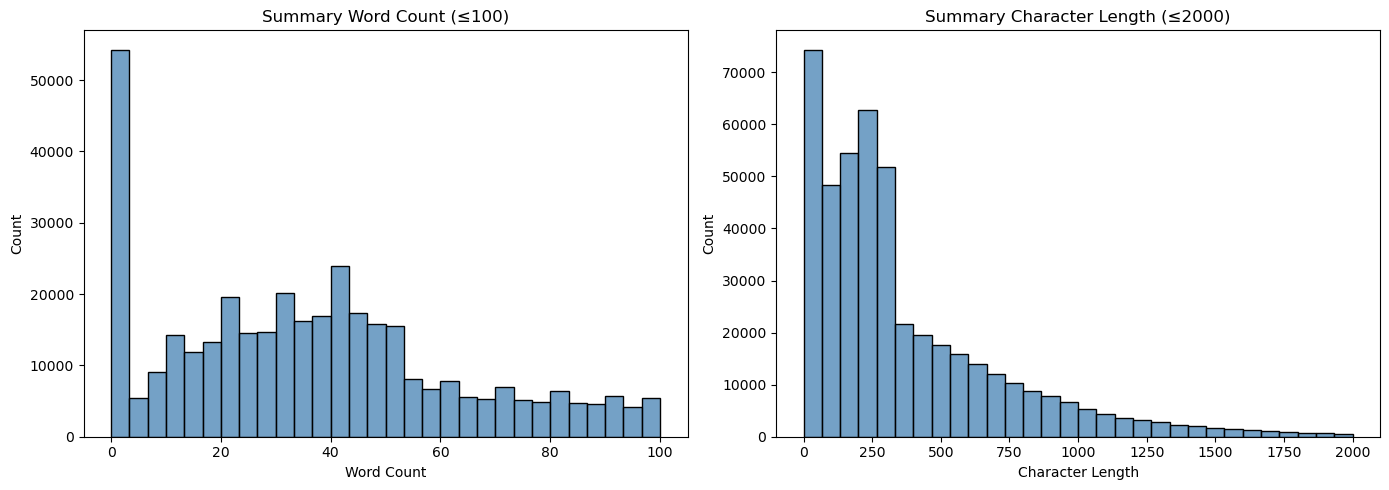

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_limit = 100
sns.histplot(merged_df[merged_df['summary_word_count'] <= summary_limit]['summary_word_count'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Word Count')
axes[0].set_title(f'Summary Word Count (≤{summary_limit})')

char_limit = 2000
sns.histplot(merged_df[merged_df['summary_length'] <= char_limit]['summary_length'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_xlabel('Character Length')
axes[1].set_title(f'Summary Character Length (≤{char_limit})')

plt.tight_layout()
plt.show()

## 5. Genre Analysis

In [19]:
print(f"Non-null genres: {merged_df['genres'].notna().sum()} ({merged_df['genres'].notna().sum()/len(merged_df)*100:.2f}%)")

genre_samples = merged_df['genres'].dropna().sample(500, random_state=42)
print("\nGenre samples (checking for non-English):")
for g in genre_samples.unique()[:30]:
    print(f"  {g}")

Non-null genres: 395905 (85.55%)

Genre samples (checking for non-English):
  Action, Horror
  Board Game
  Indie
  Indie, Simulator
  Adventure, Indie, Role-playing (RPG), Strategy
  Adventure
  Racing
  Action, Puzzle, Strategy
  Adventure, Indie, Point-and-click, Puzzle, Visual Novel
  Adventure, Indie, Platform, Puzzle, Role-playing (RPG), adventure, platformer, puzzle
  Indie, Strategy
  Arcade, Indie, Puzzle, Shooter
  Board Game, Puzzle, Strategy
  Adventure, Indie, Shooter
  Arcade, Indie, Sport
  Board Game, Strategy
  Adventure, Interactive Fiction
  Action, Platform
  arcade, fighting
  Visual Novel
  Adventure, Interactive Movie
  Adventure, Platform
  Strategy
  action, fighting
  Role-Playing
  Indie, Sport, Sports, Strategy
  Card & Board Game, Indie, Strategy, Tactical, Turn-based strategy (TBS)
  Board Game, Card & Board Game, Puzzle
  Indie, Role-playing (RPG), Shooter
  Action


In [20]:
portuguese_words = ['Ação', 'Plataforma', 'Quebra-Cabeças', 'Quebra-cabeças', 'Estratégia', 'Simulação', 'Corrida', 'Jogos de RPG', 'Jogos De RPG', 'Tiro', 'Luta', 'Briga de rua', 'Briga De Rua', 'Esporte', 'Aventura', 'Variados', 'Cassino', 'Pinball', 'Educacional']
pt_genres = merged_df[merged_df['genres'].apply(lambda x: any(w in str(x) for w in portuguese_words) if isinstance(x, str) else False)]
print(f"Entries with Portuguese genre terms: {len(pt_genres)} ({len(pt_genres)/len(merged_df)*100:.2f}%)")
print("\nPortuguese genre examples:")
print(pt_genres['genres'].value_counts().head(20))

Entries with Portuguese genre terms: 2691 (0.58%)

Portuguese genre examples:
genres
Pinball                              1719
Arcade, Pinball, Simulator            115
Arcade, Pinball                        88
Ação                                   61
Pinball, Simulator                     36
Action, Pinball                        31
Esporte                                18
Arcade, Indie, Pinball, Simulator      17
Quebra-cabeças-Ação                    16
Plataforma                             16
Quebra-cabeças                         14
Arcade, Pinball, Simulator, Sport      12
Shoot'em Up-Ação                       12
Arcade, Indie, Pinball                 12
Indie, Pinball, Simulator              11
Corrida, Pilotagem                     11
Pinball, Sport                         11
Jogos de RPG                           11
Luta-Ação                              10
Indie, Pinball                         10
Name: count, dtype: int64


In [21]:
all_genres = merged_df['genres'].dropna().str.split(',').explode().str.strip()
lower_genres = all_genres.str.lower()
inconsistent = all_genres[lower_genres != all_genres]
print(f"Genre entries with mixed/uppercase: {inconsistent.nunique()}")
print("\nExamples:")
print(inconsistent.value_counts().head(20))

Genre entries with mixed/uppercase: 170

Examples:
genres
Indie                        137184
Adventure                    127210
Strategy                      57630
Puzzle                        56087
Simulator                     53519
Role-playing (RPG)            48138
Shooter                       45917
Platform                      41142
Arcade                        40246
Action                        32432
Sport                         20068
Visual Novel                  19878
Racing                        18686
Fighting                      12270
Role-Playing                  11825
Sports                        11281
Point-and-click               10230
Card & Board Game              8049
Turn-based strategy (TBS)      7687
Beat 'em up                    7358
Name: count, dtype: int64


## 6. Release Date & Year Analysis

In [22]:
print(f"Non-null release_date: {merged_df['release_date'].notna().sum()} ({merged_df['release_date'].notna().sum()/len(merged_df)*100:.2f}%)")
print(f"Non-null release_year: {merged_df['release_year'].notna().sum()} ({merged_df['release_year'].notna().sum()/len(merged_df)*100:.2f}%)")

valid_dates = merged_df[merged_df['release_date'].notna() & merged_df['release_year'].notna()].copy()
if len(valid_dates) > 0:
    computed_year = valid_dates['release_date'].dt.year
    mismatched = valid_dates[computed_year != valid_dates['release_year']]
    print(f"\nDate/year mismatches: {len(mismatched)} ({len(mismatched)/len(valid_dates)*100:.2f}%)")
    if len(mismatched) > 0:
        print("\nExamples:")
        print(mismatched[['name', 'platform', 'release_date', 'release_year']].head(10))

Non-null release_date: 338650 (73.18%)
Non-null release_year: 59392 (12.83%)

Date/year mismatches: 4172 (25.13%)

Examples:
                           name                       platform release_date  \
98                       0-to-X  Nintendo Entertainment System   2016-12-31   
591               10-Yard Fight                  Microsoft MSX   1983-12-01   
605        10 out of 10 English                Commodore Amiga   1992-12-31   
620   10 out of 10 Maths Number                Commodore Amiga   1992-12-31   
1333            12 Family Games                    Nintendo DS   1980-01-01   
1478                   123-Talk                         MS-DOS   1991-12-31   
1804                       1869                Commodore Amiga   1992-12-31   
1873                       1942                    Amstrad CPC   1984-11-30   
1897               1942 Mission           Sinclair ZX Spectrum   1986-03-31   
1900       1942 (PlayChoice-10)                         Arcade   1987-01-01   

     

In [23]:
valid_years = merged_df[merged_df['release_year'].notna()]['release_year']
print(f"Year range: {valid_years.min()} - {valid_years.max()}")

old_games = merged_df[(merged_df['release_year'].notna()) & (merged_df['release_year'] < 1970)]
print(f"Games with release_year < 1970: {len(old_games)}")
if len(old_games) > 0:
    print("\nExamples:")
    print(old_games[['name', 'platform', 'release_year']].head(10))

future_games = merged_df[(merged_df['release_year'].notna()) & (merged_df['release_year'] > 2026)]
print(f"Games with release_year > 2026: {len(future_games)}")
if len(future_games) > 0:
    print("\nExamples:")
    print(future_games[['name', 'platform', 'release_year']].head(10))

Year range: 19 - 2025
Games with release_year < 1970: 934

Examples:
                 name platform  release_year
326    1 Million B.C.   Arcade          1968
3043          3 Coins  Pinball          1962
3211        3-In-Line  Pinball          1963
4450          4 Roses  Pinball          1962
4596      42nd Street  Pinball          1933
4869           5 Star  Pinball          1951
5590         "8 Ball"  Pinball          1952
10821        Ace High  Pinball          1957
11316          Action  Pinball          1969
18780           Aloha  Pinball          1961
Games with release_year > 2026: 0


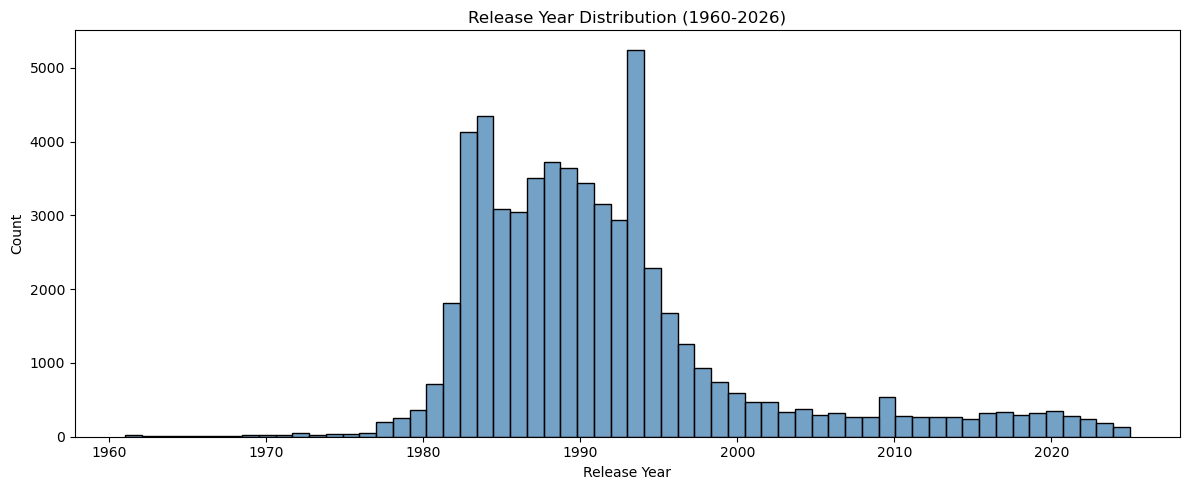

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
valid_years_filtered = merged_df[merged_df['release_year'].notna() & (merged_df['release_year'] > 1960) & (merged_df['release_year'] <= 2026)]['release_year']
sns.histplot(valid_years_filtered, bins=60, ax=ax, color='steelblue')
ax.set_xlabel('Release Year')
ax.set_title('Release Year Distribution (1960-2026)')
plt.tight_layout()
plt.show()

## 7. Developer & Publisher Analysis

In [25]:
print(f"Non-null developer: {merged_df['developer'].notna().sum()} ({merged_df['developer'].notna().sum()/len(merged_df)*100:.2f}%)")
print(f"Unique developers: {merged_df['developer'].nunique()}")
print(f"Non-null publisher: {merged_df['publisher'].notna().sum()} ({merged_df['publisher'].notna().sum()/len(merged_df)*100:.2f}%)")
print(f"Unique publishers: {merged_df['publisher'].nunique()}")

Non-null developer: 333066 (71.97%)
Unique developers: 76268
Non-null publisher: 302939 (65.46%)
Unique publishers: 55196


In [26]:
nintendo_devs = merged_df[merged_df['developer'].str.contains('Nintendo', case=False, na=False)]['developer'].unique()
print("Nintendo developer variants:")
for d in sorted(nintendo_devs):
    print(f"  {d}")

nintendo_pubs = merged_df[merged_df['publisher'].str.contains('Nintendo', case=False, na=False)]['publisher'].unique()
print("\nNintendo publisher variants:")
for p in sorted(nintendo_pubs):
    print(f"  {p}")

Nintendo developer variants:
  ACQUIRE Corp., Nintendo
  ASCII Entertainment, Nintendo
  Arika, Nintendo
  Arika, Nintendo SPD Production Group No. 2, Nintendo
  Artoon, Nintendo
  Arzest, Good-Feel, Nintendo, Chunsoft, Prope
  Asmik Ace Entertainment, Nintendo
  Atari, Tengen (Nintendo of America license)
  Atlus (Nintendo of America license)
  Camelot Software Planning, Nintendo
  Capcom USA (Nintendo of America license)
  Cygames, Nintendo EPD
  Denso-Ten, Nintendo
  Eighting, Nintendo
  Eighting, Nintendo EPD
  Fuse Games, Nintendo
  Game Freak, Nintendo
  Good-Feel, Nintendo
  Grezzo, Nintendo EPD
  Grezzo, Nintendo EPD Production Group No. 6
  HAL Laboratory, Nintendo
  Headstrong Games, Nintendo SPD
  Hudson Soft, Nintendo
  Intelligent Systems, Nintendo
  Intelligent Systems, Nintendo EPD
  Intelligent Systems, Nintendo EPD Production Group No. 6
  Intelligent Systems, Nintendo EPD Production Group No. 6, Nintendo
  Intelligent Systems, Nintendo R&D1
  Intelligent Systems, Nint

In [27]:
placeholder_patterns = ['unknown', 'n/a', 'none', '-', 'null', '']
for field in ['developer', 'publisher']:
    placeholders = merged_df[merged_df[field].notna() & merged_df[field].str.lower().isin(placeholder_patterns)]
    print(f"{field} placeholder entries: {len(placeholders)}")
    if len(placeholders) > 0:
        print(f"  Values: {placeholders[field].value_counts().to_dict()}")

developer placeholder entries: 535
  Values: {'Unknown': 323, 'unknown': 212}
publisher placeholder entries: 19
  Values: {'Unknown': 18, 'none': 1}


## 8. Players & Cooperative Analysis

In [28]:
print(f"Non-null players: {merged_df['players'].notna().sum()} ({merged_df['players'].notna().sum()/len(merged_df)*100:.2f}%)")
print(f"Non-null cooperative: {merged_df['cooperative'].notna().sum()} ({merged_df['cooperative'].notna().sum()/len(merged_df)*100:.2f}%)")

player_samples = merged_df['players'].dropna().astype(str).sample(50, random_state=42)
print("\nPlayer value samples:")
for p in player_samples.unique()[:20]:
    print(f"  {p}")

Non-null players: 141838 (30.65%)
Non-null cooperative: 158298 (34.21%)

Player value samples:
  4.0
  1.0
  2.0
  6.0


## 9. Rating Analysis

In [29]:
print(f"Non-null rating: {merged_df['rating'].notna().sum()} ({merged_df['rating'].notna().sum()/len(merged_df)*100:.2f}%)")
print(f"Non-null user_rating: {merged_df['user_rating'].notna().sum()} ({merged_df['user_rating'].notna().sum()/len(merged_df)*100:.2f}%)")

if merged_df['rating'].notna().sum() > 0:
    print("\nRating statistics:")
    print(merged_df['rating'].describe())

out_of_range_ratings = merged_df[(merged_df['rating'].notna()) & ((merged_df['rating'] < 1) | (merged_df['rating'] > 10))]
print(f"\nRatings outside 1-10 range: {len(out_of_range_ratings)}")
if len(out_of_range_ratings) > 0:
    print("Examples:")
    print(out_of_range_ratings[['name', 'platform', 'rating']].head(10))

Non-null rating: 78185 (16.89%)
Non-null user_rating: 137833 (29.78%)

Rating statistics:
count      78185.0
mean     68.312311
std      12.541265
min           10.0
25%           60.0
50%           70.0
75%           78.0
max          100.0
Name: rating, dtype: Float64

Ratings outside 1-10 range: 78180
Examples:
                       name            platform  rating
51            'Splosion Man  Microsoft Xbox 360      84
65      'n Verlore Verstand             Windows      70
74                   0 A.D.             Windows      80
77    0 Day Attack on Earth  Microsoft Xbox 360      41
90                  0°N 0°W             Windows      70
153            007: Legends  Microsoft Xbox 360      54
172  007: Quantum of Solace  Microsoft Xbox 360      65
181              007 Racing    Sony PlayStation      63
201                   03.04             Windows      60
212               0Rbitalis             Windows      73


## 10. Filename Analysis

In [30]:
print(f"Non-null filename: {merged_df['filename'].notna().sum()} ({merged_df['filename'].notna().sum()/len(merged_df)*100:.2f}%)")

if merged_df['filename'].notna().sum() > 0:
    extensions = merged_df['filename'].str.extract(r'\.(\w+)$', expand=False)
    print("\nFile extension distribution:")
    print(extensions.value_counts().head(15))

Non-null filename: 36364 (7.86%)

File extension distribution:
Series([], Name: count, dtype: int64)


## 11. Duplicate Analysis

In [31]:
exact_dups = merged_df.duplicated(subset=['name', 'platform'], keep=False)
print(f"Exact duplicates (name + platform): {exact_dups.sum()}")

dup_groups = merged_df.groupby(['name', 'platform']).filter(lambda x: len(x) > 1)
print(f"Rows in duplicate groups: {len(dup_groups)}")
print(f"Unique name+platform combos with duplicates: {dup_groups.groupby(['name', 'platform']).ngroups}")

dup_sizes = dup_groups.groupby(['name', 'platform']).size().sort_values(ascending=False)
print("\nTop 10 largest duplicate groups:")
for (name, platform), size in dup_sizes.head(10).items():
    print(f"  '{name}' on {platform}: {size} entries")

Exact duplicates (name + platform): 0
Rows in duplicate groups: 0
Unique name+platform combos with duplicates: 0

Top 10 largest duplicate groups:


## 12. Fuzzy Name Analysis

In [32]:
def clean_name_for_comparison(name):
    if not isinstance(name, str):
        return name
    name = re.sub(r'\s*\(USA|PAL|JAP|EUR|WORLD|REGION\)\s*', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s*\[!\]|\[a\]|\[T\+[^\]]*\]|\[M\+[^\]]*\]|\[b\]|\[C\]|\[O\]|\[S\]|\[U[^\]]*\]', '', name)
    return name.strip()

merged_df['_clean_name'] = merged_df['name'].apply(clean_name_for_comparison)
fuzzy_dups = merged_df[merged_df['_clean_name'] != merged_df['name']]
print(f"Names with region/hack tags: {len(fuzzy_dups)} ({len(fuzzy_dups)/len(merged_df)*100:.2f}%)")

cleaned_dups = merged_df.groupby('_clean_name').filter(lambda x: len(x) > 1)
print(f"Rows that would merge after name cleaning: {len(cleaned_dups)} ({len(cleaned_dups)/len(merged_df)*100:.2f}%)")

Names with region/hack tags: 11069 (2.39%)
Rows that would merge after name cleaning: 232039 (50.14%)


## 13. Data Quality Summary

Key findings from the analysis that inform the cleaning pipeline.

In [33]:
print("="*70)
print("DATA QUALITY FINDINGS SUMMARY")
print("="*70)

findings = []

missing_pct = merged_df.isnull().sum() / len(merged_df) * 100
high_missing = missing_pct[missing_pct > 30]
if len(high_missing) > 0:
    findings.append(f"HIGH MISSINGNESS (>30%): {dict(high_missing.round(1))}")
else:
    findings.append(f"Missingness: {', '.join(f'{k}: {v:.1f}%' for k, v in missing_pct[missing_pct > 0].items())}")

platform_lower = merged_df['platform'].str.lower()
lower_counts = Counter(platform_lower)
case_dups = {k: v for k, v in lower_counts.items() if v > 1}
if case_dups:
    findings.append(f"PLATFORM NAMING: {len(case_dups)} platform names have case variants ({len(merged_df['platform'].unique())} unique platforms total)")
    sony = merged_df[merged_df['platform'].str.contains('Play', case=False, na=False)]['platform'].nunique()
    if sony > 1:
        findings.append(f"  - Sony platform has {sony} distinct variants")

short = merged_df[merged_df['name'].str.len() <= 3]
if len(short) > 0:
    findings.append(f"SHORT NAMES: {len(short)} entries have names ≤3 chars")

region_pattern = r'\(USA|PAL|JAP|EUR|WORLD\)'
with_regions = merged_df[merged_df['name'].str.contains(region_pattern, case=False, na=False)]
if len(with_regions) > 0:
    findings.append(f"REGION TAGS: {len(with_regions)} names contain region tags (USA/PAL/JAP/EUR)")

rom_hack_pattern = r'\[!\]|\[a\]|\[T\+|\[M\+|\[b|\[C|\[O|\[S|\[U'
with_rom_hacks = merged_df[merged_df['name'].str.contains(rom_hack_pattern, na=False)]
if len(with_rom_hacks) > 0:
    findings.append(f"ROM HACK TAGS: {len(with_rom_hacks)} names contain ROM hack tags")

empty_summaries = merged_df['summary'].isna().sum()
short_summs = merged_df[merged_df['summary_length'] > 0]['summary_length'].nsmallest(10).mean()
long_summs = merged_df['summary_length'].max()
findings.append(f"SUMMARIES: {empty_summaries} missing, shortest={short_summs:.0f} chars, longest={long_summs} chars")

pt_genres = merged_df[merged_df['genres'].apply(lambda x: any(w in str(x) for w in ['Ação', 'Plataforma', 'Estratégia', 'Simulação']) if isinstance(x, str) else False)]
if len(pt_genres) > 0:
    findings.append(f"NON-ENGLISH GENRES: {len(pt_genres)} entries have Portuguese genre terms")

valid_dates = merged_df[merged_df['release_date'].notna() & merged_df['release_year'].notna()].copy()
if len(valid_dates) > 0:
    computed_year = valid_dates['release_date'].dt.year
    mismatches = valid_dates[computed_year != valid_dates['release_year']]
    if len(mismatches) > 0:
        findings.append(f"DATE MISMATCHES: {len(mismatches)} entries have release_date/release_year conflicts")

old_games = merged_df[(merged_df['release_year'].notna()) & (merged_df['release_year'] < 1970)]
if len(old_games) > 0:
    findings.append(f"OLD GAMES: {len(old_games)} entries have release_year < 1970")

out_of_range = merged_df[(merged_df['rating'].notna()) & ((merged_df['rating'] < 1) | (merged_df['rating'] > 10))]
if len(out_of_range) > 0:
    findings.append(f"OUT-OF-RANGE RATINGS: {len(out_of_range)} entries have ratings outside 1-10")

exact_dups = merged_df.duplicated(subset=['name', 'platform'], keep=False).sum()
findings.append(f"EXACT DUPLICATES: {exact_dups} rows share same name+platform")

for i, finding in enumerate(findings, 1):
    print(f"\n{i}. {finding}")

print("\n" + "="*70)
print("RECOMMENDED CLEANING ACTIONS")
print("="*70)
print("""
1. STRIP REGION TAGS: Remove (USA), (PAL), (JAP), (EUR), (WORLD), (REGION) from names
2. STRIP ROM HACK TAGS: Remove [!], [a], [T+...], [M+...], etc. from names
3. NORMALIZE PLATFORMS: Merge case variants and known aliases (e.g., Sony Playstation → PlayStation)
4. TRANSLATE PORTUGUESE GENRES: Map Portuguese genre terms to English equivalents
5. NORMALIZE GENRE CASING: Standardize genre capitalization
6. FIX DATE MISMATCHES: Align release_year with release_date where they conflict
7. PARSE PLAYER COUNTS: Extract numeric player counts from free-text player fields
8. VALIDATE RATINGS: Flag or cap ratings outside expected ranges
9. DEDUPLICATE: Remove exact duplicates (same name + platform) keeping best data
10. DERIVE RELEASE_YEAR: Compute from release_date where missing
""")

DATA QUALITY FINDINGS SUMMARY

1. HIGH MISSINGNESS (>30%): {'filename': np.float64(92.1), 'release_year': np.float64(87.2), 'publisher': np.float64(34.5), 'players': np.float64(69.4), 'cooperative': np.float64(65.8), 'rating': np.float64(83.1), 'user_rating': np.float64(70.2), 'version': np.float64(100.0)}

2. PLATFORM NAMING: 261 platform names have case variants (276 unique platforms total)

3.   - Sony platform has 14 distinct variants

4. SHORT NAMES: 1567 entries have names ≤3 chars

5. REGION TAGS: 3559 names contain region tags (USA/PAL/JAP/EUR)

6. ROM HACK TAGS: 54 names contain ROM hack tags

7. SUMMARIES: 52818 missing, shortest=3 chars, longest=15150 chars

8. NON-ENGLISH GENRES: 270 entries have Portuguese genre terms

9. DATE MISMATCHES: 4172 entries have release_date/release_year conflicts

10. OLD GAMES: 934 entries have release_year < 1970

11. OUT-OF-RANGE RATINGS: 78180 entries have ratings outside 1-10

12. EXACT DUPLICATES: 0 rows share same name+platform

RECOMMEN